<a href="https://colab.research.google.com/github/LeenYasser/my-ip-labs/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Morphological Operations (AI342)
**Student Name:** [Leen Yaser] | **Student ID:** [4456588]
---
### Instructions:
* Do **NOT** add or delete any cells.
* Task 1 is provided as a reference. Complete the missing parts in other tasks.
* Pay attention to the variable names and the requested Structuring Elements.

## Task 1: Basic Operations & Area Analysis
In this section, we apply **Erosion**, **Dialation**, **Opening** and **Closing** and analyze the resulting object areas. Also, we compare a custom **Square Structuring Element** and a **Disk Structuring Element**.
.

Original Area: 1600 pixels
Erosion Area: 1296 pixels
Dilation Area: 1936 pixels
Opening Area: 1580 pixels
Closing Area: 1600 pixels


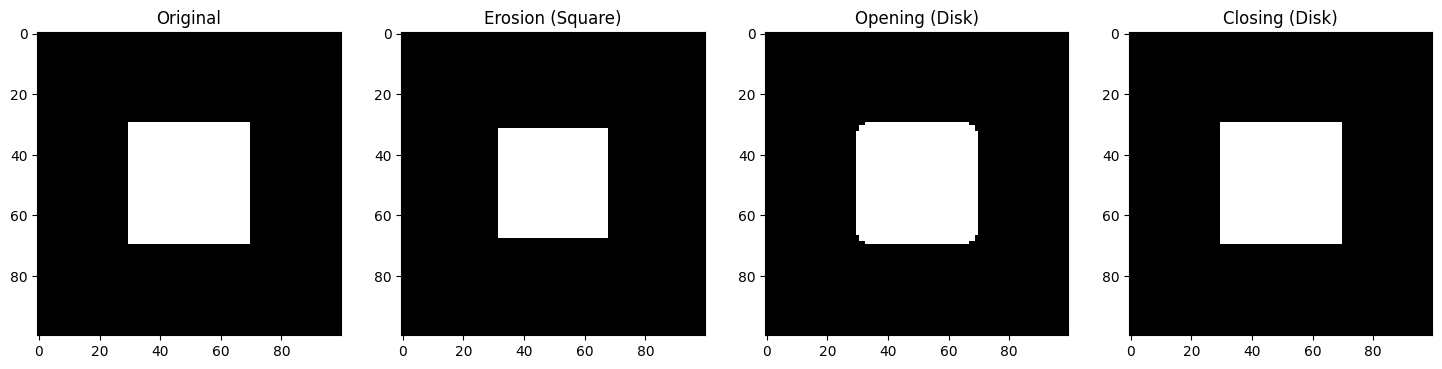

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_erosion
from skimage import morphology, data

# Setup Image
img = np.zeros((100, 100), dtype=bool)
img[30:70, 30:70] = True

# 1. Custom Square Structuring Element
se_square = np.ones((5,5), bool)
# 2. Disk Structuring Element
se_disk = morphology.disk(3)

# Applying Operations
ero_res = binary_erosion(img, structure=se_square)
dil_res = binary_dilation(img, structure=se_square)
open_res = morphology.binary_opening(img, se_disk)
close_res = morphology.binary_closing(img, se_disk)

# Area Comparison
print(f"Original Area: {np.sum(img)} pixels")
print(f"Erosion Area: {np.sum(ero_res)} pixels")
print(f"Dilation Area: {np.sum(dil_res)} pixels")
print(f"Opening Area: {np.sum(open_res)} pixels")
print(f"Closing Area: {np.sum(close_res)} pixels")

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(ero_res, cmap='gray'); axes[1].set_title("Erosion (Square)")
axes[2].imshow(open_res, cmap='gray'); axes[2].set_title("Opening (Disk)")
axes[3].imshow(close_res, cmap='gray'); axes[3].set_title("Closing (Disk)")
plt.show()

---
**Q1: Based on the printed area values, why did the area decrease in Erosion/Opening and increase in Dilation/Closing?**

Basically, Erosion/Opening reduce the area by eating at the edges. Dilation/Closing increase the area by padding the edges and closing up gaps.

## Task 2: Boundary Extraction
**Formula:** $Boundary = A \oplus (A \ominus B)$
**Note:** Use **Logical XOR** (`^` or `np.logical_xor`) instead of set difference.

**Requirement:** Apply boundary extraction using two different Disk sizes: `disk(1)` and `disk(3)`.

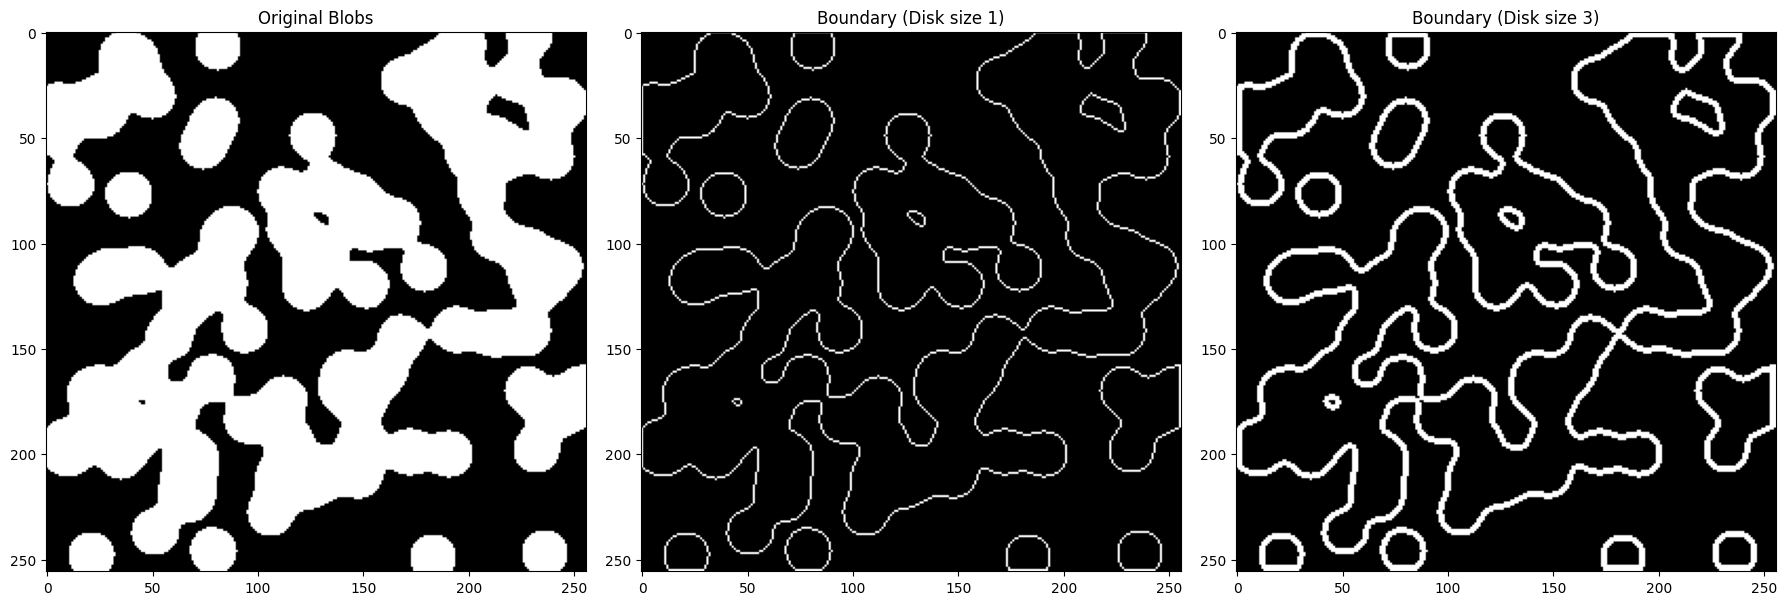

In [6]:
# TODO: Implement Boundary Extraction
# Use 'binary_img' (Blobs) for this task
rng = np.random.default_rng(seed=42)
binary_img = data.binary_blobs(length=256, blob_size_fraction=0.1, rng=rng)

# 1. Extract boundary using morphology.disk(1)
se1 = morphology.disk(1)
boundary_disk1 = binary_img ^ binary_erosion(binary_img, structure=se1)

# 2. Extract boundary using morphology.disk(3)
se3 = morphology.disk(3)
boundary_disk3 = binary_img ^ binary_erosion(binary_img, structure=se3)

# 3. Display the results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(binary_img, cmap='gray')
axes[0].set_title("Original Blobs")

axes[1].imshow(boundary_disk1, cmap='gray')
axes[1].set_title("Boundary (Disk size 1)")

axes[2].imshow(boundary_disk3, cmap='gray')
axes[2].set_title("Boundary (Disk size 3)")

plt.tight_layout()
plt.show()

---
**Q2: Compare the boundaries extracted using disk(1) and disk(3). What is the effect of SE size on the boundary?**

If we use a larger SE like Disk 3, the boundary gets thicker. Basically, the larger SE erodes more of the interior pixels, so when you XOR it with the original image, you’re left with a wider gap.


# Task 3: Controlled Thinning & Thickening
**Mathematical Note:**

Since the library does not provide a direct thick function, we use the Duality Principle:
Thickening an image $A$ is equivalent to thinning the complement of $A$ ($A^c$), then complementing the result:$$\text{Thickening}(A) = \text{Thinning}(A^c)^c$$

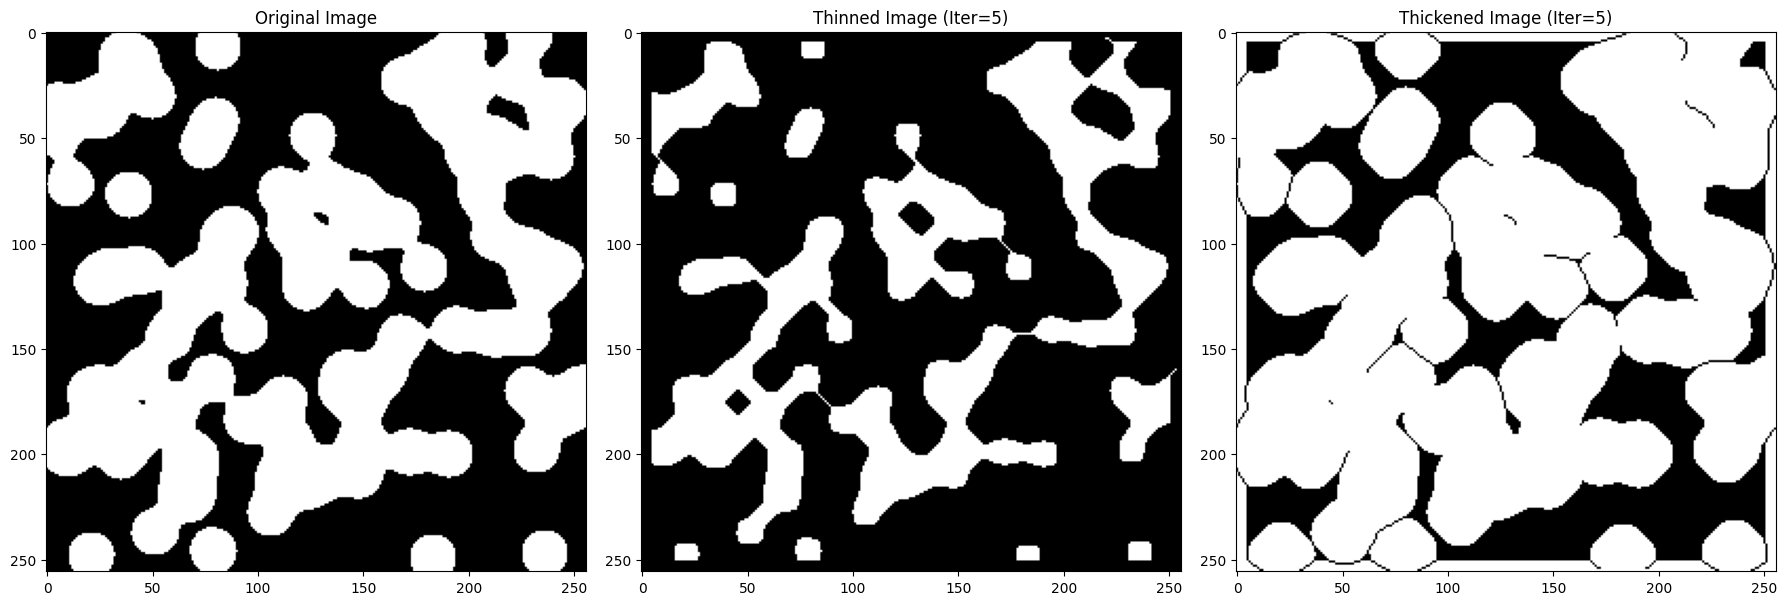

In [7]:
# --- STUDENT CODE HERE ---
# 1. Apply Thinning with max_num_iter = 5
# 2. Apply Thickening with max_num_iter = 5
# Note: Use the duality principle for thickening: ~thin(~image)
# 3. Display the Original, Thinned, and Thickened images side-by-side.

# [Your Code Starts]

# 1. Apply Thinning with max_num_iter = 5
thinned_img = morphology.thin(binary_img, max_num_iter=5)

# 2. Apply Thickening with max_num_iter = 5
thickened_img = ~morphology.thin(~binary_img, max_num_iter=5)

# 3. Display the Original, Thinned, and Thickened images side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(binary_img, cmap='gray')
axes[0].set_title("Original Image")

axes[1].imshow(thinned_img, cmap='gray')
axes[1].set_title("Thinned Image (Iter=5)")

axes[2].imshow(thickened_img, cmap='gray')
axes[2].set_title("Thickened Image (Iter=5)")

plt.tight_layout()
plt.show()

# [Your Code Ends]

---
**Q3: How does Thinning differ from Erosion in terms of shape preservation?**

Thinning is better for keeping the object's skeleton and connections intact while making it smaller. Erosion just shrinks everything down, which means you might lose important details or structural parts in the process.

## Task 4: Hit-or-Miss End-Point Detection
**Objective:** Detect all ridge endings using a rotating Structuring Element.
**Formula:** $A \circledast B = (A \ominus B_1) \cap (A^c \ominus B_2)$

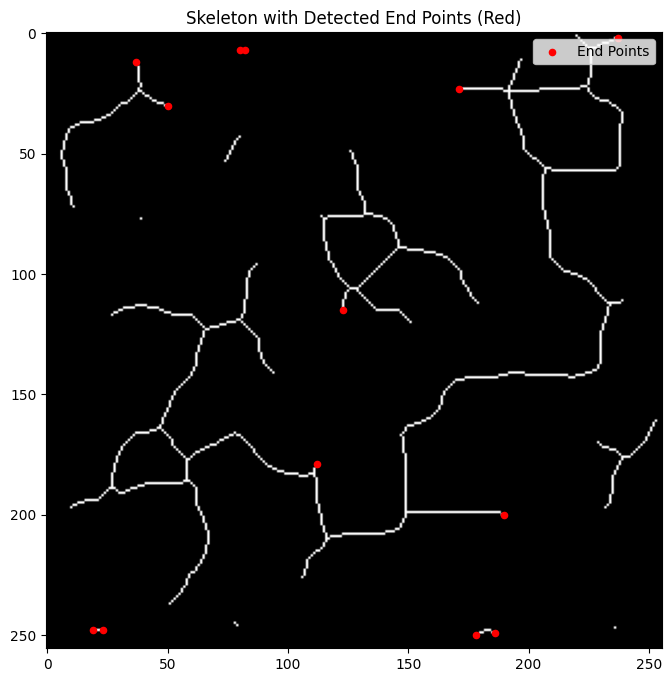

In [8]:
from scipy.ndimage import binary_hit_or_miss
from skimage.morphology import skeletonize

# Prepare Skeleton
skeleton = skeletonize(binary_img)

# Define the Base Structuring Element (End-point pattern)
se_base = np.array([[0, 0, 0],
                    [0, 1, 0],
                    [0, 1, 0]], dtype=bool)

# --- CODE STRUCTURE (Complete the missing parts) ---
all_end_points = np.zeros_like(skeleton, dtype=bool)

# Loop to detect endings in all 4 directions

for i in range(4):
    # TODO: Rotate the 'se_base' by 90 degrees 'i' times
    # use np.rot90(m, k) where m is SE
    # and k: The number of times the array is rotated by 90 degrees.
    se_rotated = np.rot90(se_base, k=i)

    # TODO: Apply binary_hit_or_miss
    detected = binary_hit_or_miss(skeleton, structure1=se_rotated)

    # Combine results
    all_end_points |= detected

# Visualization (Final Result Overlay)
plt.figure(figsize=(8, 8))
plt.imshow(skeleton, cmap='gray')
y, x = np.where(all_end_points)
plt.scatter(x, y, color='red', s=20, label='End Points')
plt.title("Skeleton with Detected End Points (Red)")
plt.legend()
plt.show()

---
**Q4: In the Hit-or-Miss logic, what does the '1' and '0' in our Structuring Element represent?**

1 means a pixel must be there (Hit), and 0 means it must be empty (Miss). It only matches if both are true.